In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [2]:
df=pd.read_csv(r"C:\Users\Parth\Downloads\Plant_1_Weather_Sensor_Data.csv")

In [3]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [4]:
df['DATE_TIME']=pd.to_datetime(df['DATE_TIME'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   datetime64[ns]
 1   PLANT_ID             3182 non-null   int64         
 2   SOURCE_KEY           3182 non-null   object        
 3   AMBIENT_TEMPERATURE  3182 non-null   float64       
 4   MODULE_TEMPERATURE   3182 non-null   float64       
 5   IRRADIATION          3182 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 149.3+ KB


In [8]:
df.set_index('DATE_TIME',inplace=True)

In [9]:
df.head()

,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,,
2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [12]:
df.drop(columns=['PLANT_ID','SOURCE_KEY'],inplace=True)

In [13]:
df.head()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,
2020-05-15 00:00:00,25.184316,22.857507,0.0
2020-05-15 00:15:00,25.084589,22.761668,0.0
2020-05-15 00:30:00,24.935753,22.592306,0.0
2020-05-15 00:45:00,24.846130,22.360852,0.0
2020-05-15 01:00:00,24.621525,22.165423,0.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3182 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AMBIENT_TEMPERATURE  3182 non-null   float64
 1   MODULE_TEMPERATURE   3182 non-null   float64
 2   IRRADIATION          3182 non-null   float64
dtypes: float64(3)
memory usage: 99.4 KB


In [15]:
print(df.index.dtype)

datetime64[ns]


In [16]:
features=['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']
target_column='IRRADIATION'

In [17]:
scaler=MinMaxScaler()
scaled=scaler.fit_transform(df[features])

In [20]:
def create_sequences(data, seq_len, target_index):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :])  # All features
        y.append(data[i+seq_len, target_index])  # Predict next total yield
    return np.array(X), np.array(y)

seq_len = 13 
target_index = features.index(target_column)
X, y = create_sequences(scaled, seq_len, target_index)

In [21]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [22]:
model = Sequential([
    LSTM(64, input_shape=(seq_len, len(features)), return_sequences=True),  # First LSTM layer
    LSTM(32, return_sequences=False),  # Second LSTM layer

    Dense(64, activation='relu'),  # First dense hidden layer
    Dense(32, activation='relu'),  # Second dense hidden layer
    Dense(16, activation='relu'),  # Third dense hidden layer

    Dense(1)  # Output layer
])
model.compile(optimizer='adam', loss='mse')
model.summary()

C:\Users\Parth\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 13, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,561 (135.00 KB)

 Trainable params: 34,561 (135.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0051 - val_loss: 0.0043
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0055 - val_loss: 0.0041
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0062 - val_loss: 0.0042
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0056 - val_loss: 0.0041
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 8/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0050 - val_loss: 0.0041
Epoch 9/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0056 - val_loss: 0.0039
Epoch 10/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0048 - val_loss: 0.0044
Epoch 11/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0056 - val_loss: 0.0039
Epoch 12/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0

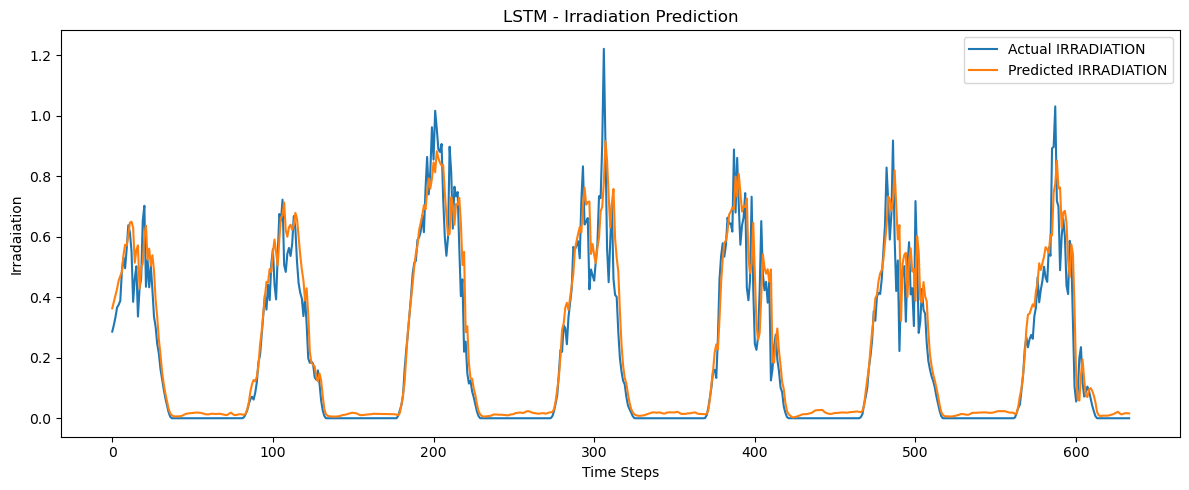

In [24]:
# 8. Train the model
model.fit(X_train, y_train, epochs=40, batch_size=64, validation_split=0.1)

# 9. Make predictions
y_pred = model.predict(X_test)

# 10. Inverse transform predictions and actuals
target_scaler = MinMaxScaler()
target_scaler.min_, target_scaler.scale_ = scaler.min_[target_index:target_index+1], scaler.scale_[target_index:target_index+1]
y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

# 11. Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual, label='Actual IRRADIATION')
plt.plot(y_pred_actual, label='Predicted IRRADIATION')
plt.title("LSTM - Irradiation Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Irradaiation")
plt.legend()
plt.tight_layout()
plt.show()

# New Data set

In [26]:
df=pd.read_csv(r"C:\Users\Parth\Downloads\solar_data.csv")

In [27]:
df.head()

,Timestamp,Air_Temp,Relative_Humidity,Wind_Speed,Wind_Direction,Solar_Radiation,RTD_1,RTD_2,RTD_3,RTD_4,RTD_5,Array_Voltage,Array_Current,Power_Generated
0,27-04-2022 15:32,43.349172,12.790256,0.533333,118.786620,707.53384,98.289640,94.283552,89.002824,93.334288,94.142984,80.178232,5.364869,430.14572
1,27-04-2022 15:34,43.433980,11.468986,1.866667,84.681408,710.46328,98.377480,94.177872,89.334664,93.633208,94.107592,80.266728,5.366041,430.71452
2,27-04-2022 15:36,43.286580,11.047298,2.866667,40.807156,695.51016,97.868064,93.703480,88.844592,92.982568,93.650656,80.187416,5.365501,430.24568
3,27-04-2022 15:38,43.523020,12.058292,0.000000,66.390848,696.24472,101.470960,97.112320,91.963472,96.146384,97.147776,80.727760,5.364512,433.06504
4,27-04-2022 15:40,43.728656,10.722330,2.266667,2.127408,674.05752,101.664240,97.253520,91.980872,96.110968,97.341296,80.500312,5.365144,431.89576


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1009 non-null   object 
 1   Air_Temp           1009 non-null   float64
 2   Relative_Humidity  1009 non-null   float64
 3   Wind_Speed         1009 non-null   float64
 4   Wind_Direction     1009 non-null   float64
 5   Solar_Radiation    1009 non-null   float64
 6   RTD_1              1009 non-null   float64
 7   RTD_2              1009 non-null   float64
 8   RTD_3              1009 non-null   float64
 9   RTD_4              1009 non-null   float64
 10  RTD_5              1009 non-null   float64
 11  Array_Voltage      1009 non-null   float64
 12  Array_Current      1009 non-null   float64
 13  Power_Generated    1009 non-null   float64
dtypes: float64(13), object(1)
memory usage: 110.5+ KB


In [30]:
df['Timestamp']=pd.to_datetime(df['Timestamp'],format='%d-%m-%Y %H:%M')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Timestamp          1009 non-null   datetime64[ns]
 1   Air_Temp           1009 non-null   float64       
 2   Relative_Humidity  1009 non-null   float64       
 3   Wind_Speed         1009 non-null   float64       
 4   Wind_Direction     1009 non-null   float64       
 5   Solar_Radiation    1009 non-null   float64       
 6   RTD_1              1009 non-null   float64       
 7   RTD_2              1009 non-null   float64       
 8   RTD_3              1009 non-null   float64       
 9   RTD_4              1009 non-null   float64       
 10  RTD_5              1009 non-null   float64       
 11  Array_Voltage      1009 non-null   float64       
 12  Array_Current      1009 non-null   float64       
 13  Power_Generated    1009 non-null   float64       
dtypes: datet

In [34]:
df.set_index('Timestamp',inplace=True)

In [35]:
df.head(2)

,Air_Temp,Relative_Humidity,Wind_Speed,Wind_Direction,Solar_Radiation,RTD_1,RTD_2,RTD_3,RTD_4,RTD_5,Array_Voltage,Array_Current,Power_Generated
Timestamp,,,,,,,,,,,,,
2022-04-27 15:32:00,43.349172,12.790256,0.533333,118.786620,707.53384,98.28964,94.283552,89.002824,93.334288,94.142984,80.178232,5.364869,430.14572
2022-04-27 15:34:00,43.433980,11.468986,1.866667,84.681408,710.46328,98.37748,94.177872,89.334664,93.633208,94.107592,80.266728,5.366041,430.71452


In [36]:
features=['Air_Temp','Relative_Humidity','Wind_Speed','Wind_Direction','Solar_Radiation','RTD_1','RTD_2','RTD_3','RTD_4','RTD_5','Array_Voltage','Array_Current','Power_Generated']
target_column='Power_Generated'

In [37]:
scaler=MinMaxScaler()
scaled=scaler.fit_transform(df[features])

In [42]:
def create_sequences(data, seq_len, target_index):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :])  # All features
        y.append(data[i+seq_len, target_index])  # Predict next total yield
    return np.array(X), np.array(y)

seq_len = 21 
target_index = features.index(target_column)
X, y = create_sequences(scaled, seq_len, target_index)

In [43]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [44]:

model = Sequential([
    LSTM(64, input_shape=(seq_len, len(features)), return_sequences=True),  # First LSTM layer
    LSTM(32, return_sequences=False),  # Second LSTM layer

    Dense(64, activation='relu'),  # First dense hidden layer
    Dense(32, activation='relu'),  # Second dense hidden layer
    Dense(16, activation='relu'),  # Third dense hidden layer

    Dense(1)  # Output layer
])
model.compile(optimizer='adam', loss='mse')
model.summary()

C:\Users\Parth\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 21, 64)              │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,121 (145.00 KB)

 Trainable params: 37,121 (145.00 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# 8. Train the model
model.fit(X_train, y_train, epochs=40, batch_size=64, validation_split=0.1)

# 9. Make predictions
y_pred = model.predict(X_test)

# 10. Inverse transform predictions and actuals
target_scaler = MinMaxScaler()
target_scaler.min_, target_scaler.scale_ = scaler.min_[target_index:target_index+1], scaler.scale_[target_index:target_index+1]
y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))



Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 9.7109e-04 - val_loss: 0.0015
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 9.5151e-04 - val_loss: 0.0038
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 5.4379e-04 - val_loss: 0.0014
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 6.6197e-04 - val_loss: 0.0017
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 4.5951e-04 - val_loss: 0.0017
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.2281e-04 - val_loss: 0.0021
Epoch 7/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 3.1177e-04 - val_loss: 0.0017
Epoch 8/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 6.5677e-04 - val_loss: 0.0040
Epoch 9/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 6.1578e-04 - val_loss: 0.0014
Epoch 10/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 3.8037e-04 - val_loss: 0.0014
Epoch 11/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 2.5235e-04 - val_loss: 0.0043
Epoch 12/40
12/12 ━

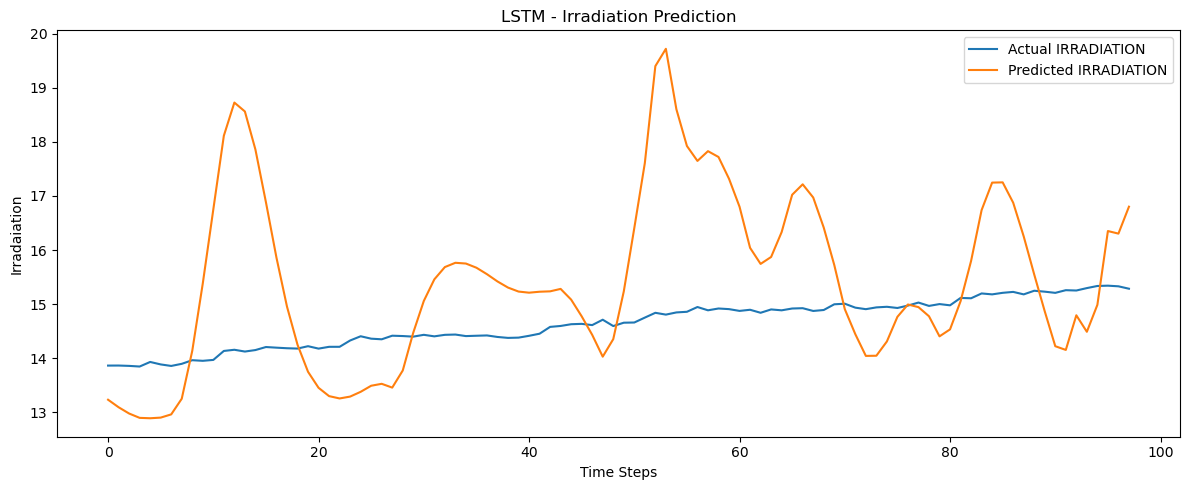

In [48]:
# 11. Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[100:], label='Actual IRRADIATION')
plt.plot(y_pred_actual[100:], label='Predicted IRRADIATION')
plt.title("LSTM - Irradiation Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Irradaiation")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# USING TRANSFORMER

In [62]:
def create_sequences(data, seq_len, target_index):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :])  # All features
        y.append(data[i+seq_len, target_index])  # Predict next total yield
    return np.array(X), np.array(y)

seq_len = 53 
target_index = features.index(target_column)
X, y = create_sequences(scaled, seq_len, target_index)

In [63]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [64]:
import tensorflow as tf
import numpy as np

def get_positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    # Apply sin to even indices, cos to odd
    pos_encoding = np.zeros(angle_rads.shape)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)


In [65]:
from tensorflow.keras.layers import LayerNormalization, MultiHeadAttention, Dense, Dropout, Input, Layer
from tensorflow.keras.models import Model

class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=None):  # <- Make 'training' optional
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
    
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


In [66]:
def build_transformer_model(seq_len, num_features, embed_dim=64, num_heads=4, ff_dim=128):
    inputs = Input(shape=(seq_len, num_features))
    
    # Project inputs to embedding dimension
    x = Dense(embed_dim)(inputs)
    
    # Add positional encoding
    pos_encoding = get_positional_encoding(seq_len, embed_dim)
    x += pos_encoding
    
    # Transformer block
    x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(1)(x)  # Output layer for regression
    
    model = Model(inputs=inputs, outputs=x)
    return model


In [67]:
model = build_transformer_model(seq_len=53, num_features=13)
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train
model.fit(X_train, y_train, validation_split=0.2, epochs=40, batch_size=64)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 53, 13)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 53, 64)              │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add_2 (Add)                          │ (None, 53, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_2                  │ (None, 53, 64)              │          83,200 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,321 (345.00 KB)

 Trainable params: 88,321 (345.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - loss: 0.5163 - val_loss: 0.1309
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 0.0975 - val_loss: 0.0047
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - loss: 0.0524 - val_loss: 0.0056
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0270 - val_loss: 0.0050
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0206 - val_loss: 0.0046
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0155 - val_loss: 0.0076
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0116 - val_loss: 0.0023
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0075 - val_loss: 0.0026
Epoch 9/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.0059 - val_loss: 0.0029
Epoch 10/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0050 - val_loss: 0.0032
Epoch 11/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 12/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - los

In [68]:
y_pred = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [69]:
y_pred = y_pred.flatten()
y_test = y_test.flatten()


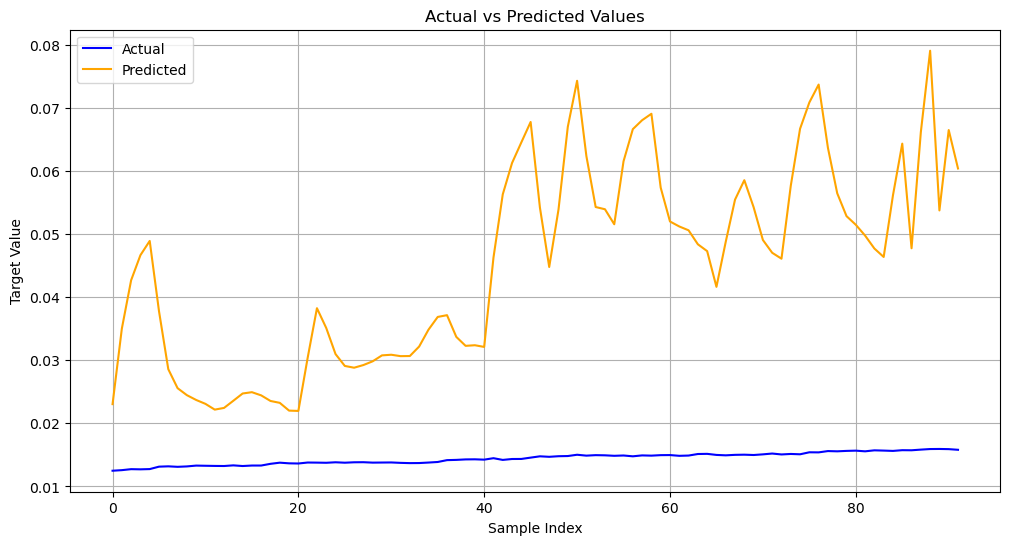

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test[100:], label='Actual', color='blue')
plt.plot(y_pred[100:], label='Predicted', color='orange')
plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)
plt.show()

